# Практическое задание №2

## Задание
Используйте файл с информацией о ноутбуках `laptops_na.csv`.

[Источник данных](https://www.kaggle.com/datasets/bhavikjikadara/brand-laptops-dataset)


В нём содержаться следующие переменные:

- `brand`: Название бренда ноутбука.
- `Model`: Конкретная модель или серия ноутбука.
- `Price`: Цена ноутбука в индийских рупиях.
- `Rating`: Рейтинг, присвоенный ноутбуку на основе его характеристик.
- `processor_brand`: Марка процессора, используемого в ноутбуке.
- `processor_tier`: Уровень производительности или категория процессора.
- `num_cores`: Количество вычислительных ядер в процессоре.
- `num_threads`: Количество потоков, поддерживаемых процессором.
- `ram_memory`: Объем оперативной памяти, используемый в ноутбуке.
- `primary_storage_type`: Тип основного хранилища (например, HDD, SSD).
- `primary_storage -apacity`: Емкость основного хранилища ноутбука.
- `secondary_storage_type`: Тип вторичного хранилища, если оно доступно.
- `secondary_storage_capacity`: Емкость вторичного хранилища ноутбука.
- `gpu_brand`: Марка графического процессора (GPU).
- `gpu_type`: Тип графического процессора.
- `is_touch_screen`: Указывает, оснащен ли ноутбук функцией сенсорного экрана.
- `display_size`: Размер дисплея ноутбука в дюймах.
- `resolution_width`: Разрешение по ширине дисплея.
- `resolution_height`: Разрешение дисплея по высоте.
- `OS`: Установленная на ноутбуке операционная система.
- `year_of_warranty`: Срок гарантии, предоставляемой на ноутбук, обычно в годах.

In [191]:
!pip install pingouin

import pandas as pd
from scipy import stats
from math import sqrt
import pingouin as pg
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, norm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [192]:
df = pd.read_csv('laptops_na.csv')
df.head()

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,secondary_storage_type,secondary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty
0,1.0,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990.0,63.0,intel,core i3,2.0,4.0,NaN,...,No secondary storage,0.0,intel,integrated,False,15.6,1920.0,1080.0,windows,1
1,2.0,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990.0,67.0,intel,core i7,4.0,8.0,16.0,...,No secondary storage,0.0,intel,integrated,False,15.6,1920.0,1080.0,windows,1
2,3.0,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100.0,73.0,amd,ryzen 5,6.0,12.0,8.0,...,No secondary storage,0.0,amd,dedicated,False,NaN,1920.0,1080.0,windows,1
3,4.0,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990.0,62.0,intel,core i5,12.0,NaN,8.0,...,No secondary storage,0.0,intel,integrated,False,14.0,1920.0,1080.0,windows,1
4,5.0,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580.0,62.0,amd,ryzen 3,4.0,8.0,8.0,...,No secondary storage,0.0,amd,integrated,False,15.6,1920.0,1080.0,windows,1


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   index                       933 non-null    float64
 1   brand                       944 non-null    object 
 2   Model                       946 non-null    object 
 3   Price                       942 non-null    float64
 4   Rating                      936 non-null    float64
 5   processor_brand             930 non-null    object 
 6   processor_tier              950 non-null    object 
 7   num_cores                   958 non-null    float64
 8   num_threads                 953 non-null    float64
 9   ram_memory                  942 non-null    float64
 10  primary_storage_type        932 non-null    object 
 11  primary_storage_capacity    928 non-null    float64
 12  secondary_storage_type      946 non-null    object 
 13  secondary_storage_capacity  942 non

Обратите внимание, что все пункты задания должны сопровождаться _выполненным_ фрагментом кода!

### Задание 1. Проверка отличия распределения от «нормального»

Проанализируйте распределение значений 5-ти любых метрических переменных. Проведите тест для проверки того отличается ли распределение значений переменных от нормального распределения. Сформулируйте гипотезы и выводы по результатам анализа. Постройте гистограммы распределения с наложенной кривой нормального распределения.

***1. Цена***

In [194]:
stats.kstest(df['Price'].dropna(), 'norm', args=(df['Price'].dropna().mean(), df['Price'].dropna().std()))

KstestResult(statistic=np.float64(0.18025942533524242), pvalue=np.float64(2.9704447687930683e-27), statistic_location=np.float64(80020.0), statistic_sign=np.int8(1))

Используем тест на нормальность Колмогорова-Смирнова, так как наблюдений >50

H0: Распределение значений переменной "Price" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "Price" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального


<Axes: xlabel='Price', ylabel='Density'>

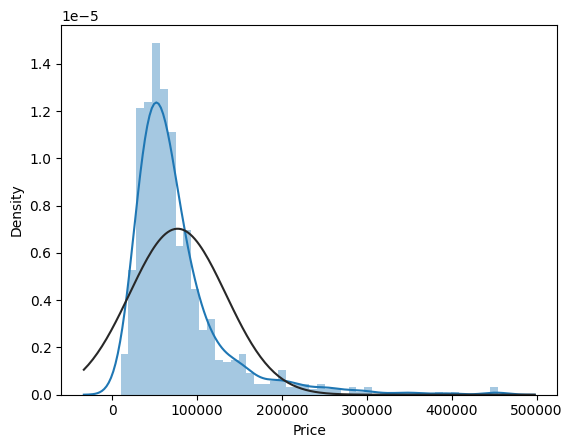

In [195]:
sns.distplot(df['Price'].dropna(), fit=norm)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

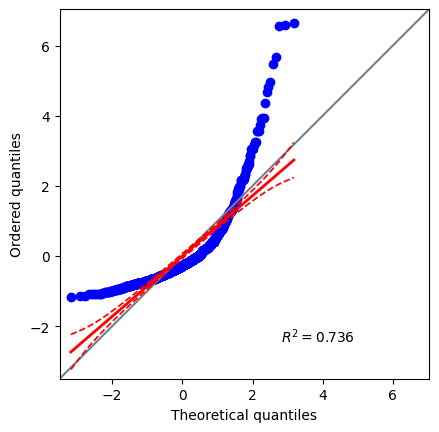

In [196]:
pg.qqplot(df['Price'], dist = 'norm')

На графике видно, что квантили в наших данных заметно отличаются от квантилей нормального распределения.

2. ***Число ядер***

In [197]:
stats.kstest(df['num_cores'].dropna(), 'norm', args=(df['num_cores'].dropna().mean(), df['num_cores'].dropna().std()))

KstestResult(statistic=np.float64(0.13179902703282986), pvalue=np.float64(5.691045015112295e-15), statistic_location=np.float64(10.0), statistic_sign=np.int8(1))

Используем тест на нормальность Колмогорова-Смирнова, так как наблюдений >50

H0: Распределение значений переменной "num_cores" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "num_cores" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального

<Axes: xlabel='num_cores', ylabel='Density'>

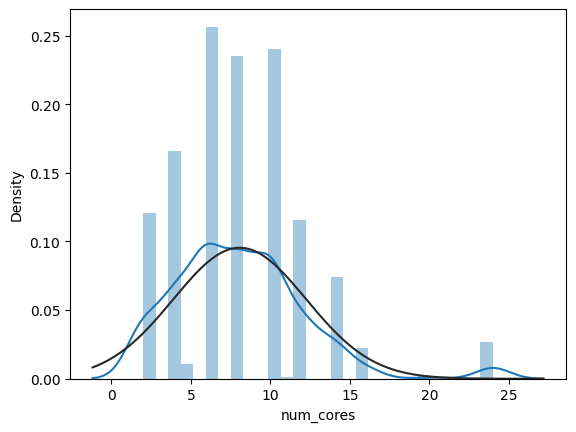

In [198]:
sns.distplot(df['num_cores'].dropna(), fit=norm)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

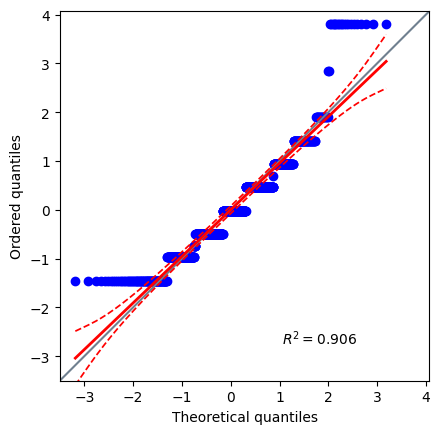

In [199]:
pg.qqplot(df['num_cores'], dist = 'norm')

По графику видно, что это не похоже на нормальное распределение

***3. Объем оперативной памяти, используемый в ноутбуке.***

In [200]:
stats.kstest(df['ram_memory'].dropna(), 'norm', args=(df['ram_memory'].dropna().mean(), df['ram_memory'].dropna().std()))

KstestResult(statistic=np.float64(0.2679305435076793), pvalue=np.float64(3.346989988862827e-60), statistic_location=np.float64(16.0), statistic_sign=np.int8(-1))

Используем тест на нормальность Колмогорова-Смирнова, так как наблюдений >50

H0: Распределение значений переменной "ram_memory" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "ram_memory" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального

<Axes: xlabel='ram_memory', ylabel='Density'>

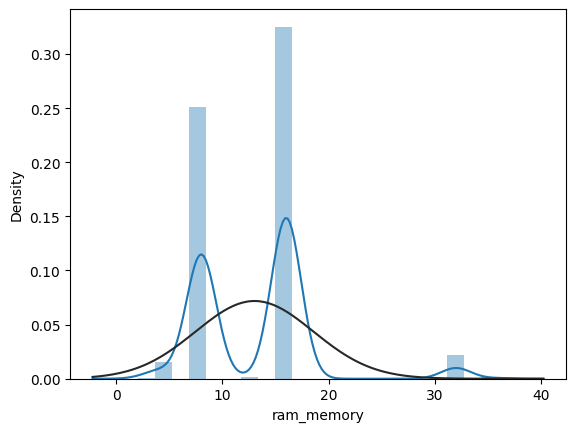

In [201]:
sns.distplot(df['ram_memory'].dropna(), fit=norm)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

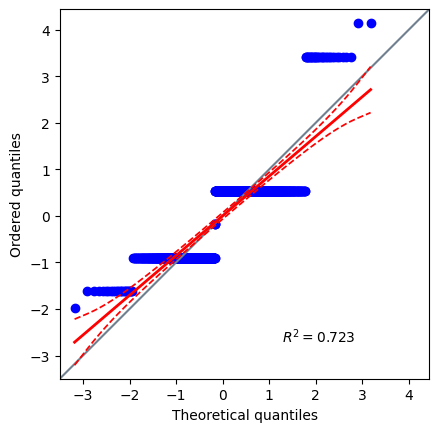

In [202]:
pg.qqplot(df['ram_memory'], dist = 'norm')

По графику видно, что это не похоже на нормальное распределение

***4. Рейтинг***

In [203]:
stats.kstest(df['Rating'].dropna(), 'norm', args=(df['Rating'].dropna().mean(), df['Rating'].dropna().std()))

KstestResult(statistic=np.float64(0.06092213797673002), pvalue=np.float64(0.0018371492092324748), statistic_location=np.float64(56.0), statistic_sign=np.int8(-1))

Используем тест на нормальность Колмогорова-Смирнова, так как наблюдений >50

H0: Распределение значений переменной "Rating" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "Rating" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального

<Axes: xlabel='Rating', ylabel='Density'>

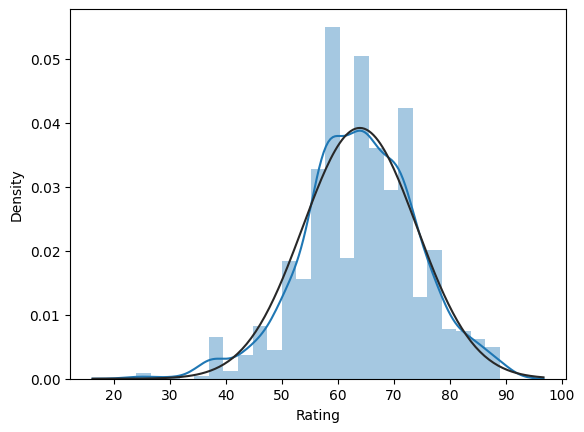

In [204]:
sns.distplot(df['Rating'].dropna(), fit=norm)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

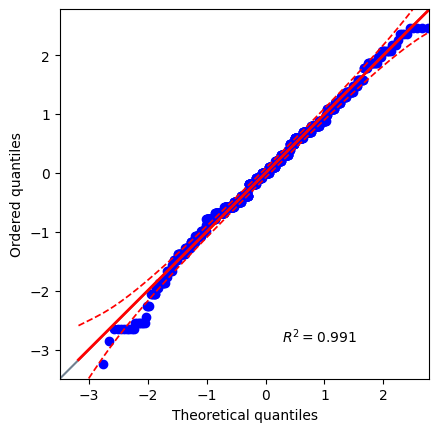

In [205]:
pg.qqplot(df['Rating'], dist = 'norm')

Похоже на нормальное распределение, но, тем не менее, p-value слишком низок, чтобы не принимать гипотезу H1

***5. Размер дисплея***

In [206]:
stats.kstest(df['display_size'].dropna(), 'norm', args=(df['display_size'].dropna().mean(), df['display_size'].dropna().std()))

KstestResult(statistic=np.float64(0.37423689422133327), pvalue=np.float64(4.3259429606749244e-119), statistic_location=np.float64(15.6), statistic_sign=np.int8(-1))

Используем тест на нормальность Колмогорова-Смирнова, так как наблюдений >50

H0: Распределение значений переменной "display_size" статистически значимо не отличается от нормального распределения.

H1: Распределение значений переменной "Rating" статистически значимо отличается от нормального распределения.

Вывод: поскольку p-value < 0.05, гипотеза H1 принимается => распределение статистически значимо отличается от нормального

<Axes: xlabel='display_size', ylabel='Density'>

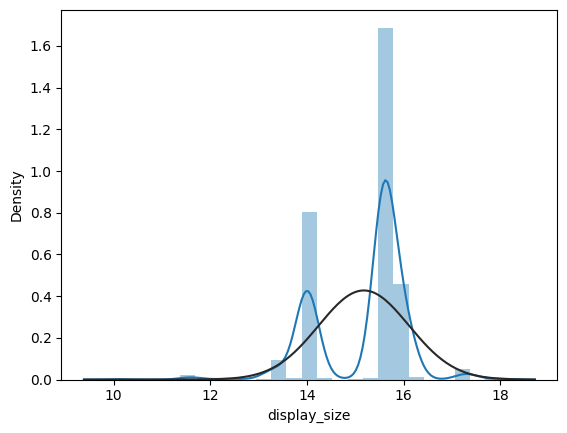

In [207]:
sns.distplot(df['display_size'].dropna(), fit=norm)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

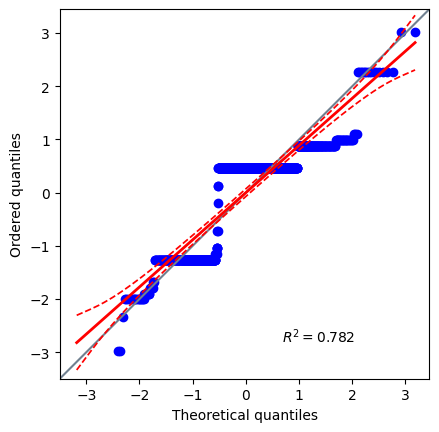

In [208]:
pg.qqplot(df['display_size'], dist = 'norm')

По графику видно, что это не нормальное распределение

### Задание 2. Тест Хи-квадрат

Проведите тест Хи-квадрат не менее, чем с двумя парами переменных, для которых он применим. Можно использовать как исходные переменные, так и перекодировать их. Постройте для выбранных пар переменных таблицы сопряженности и прокомментируйте их. Сформулируйте гипотезы. Интерпретируйте результаты анализа. Обоснуйте свои выводы. Визуализируйте наблюдаемые тенденции на подходящих графиках.

***1. Rating и Price***

In [209]:
test = pd.crosstab(df['Price'], df['Rating'])
test

Rating,24.0,26.0,31.0,35.0,37.0,38.0,39.0,41.0,43.0,44.0,...,79.0,80.0,82.0,83.0,84.0,85.0,86.0,87.0,88.0,89.0
Price,,,,,,,,,,,,,,,,,,,,,
9800.0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
11990.0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
12990.0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14701.0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14990.0,0,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359095.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
388490.0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
449990.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Создадим новые столбцы, созданные из старых, путем разделения на квантили

In [210]:
df['Rating_decile'] = pd.qcut(df['Rating'], q=10, labels=False) + 1
df['Price_decile'] = pd.qcut(df['Price'], q = 10, labels=False) + 1

In [211]:
ct_price_rating = pd.crosstab(df['Price_decile'], df['Rating_decile'])
ct_price_rating

Rating_decile,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
Price_decile,,,,,,,,,,
1.0,60,19,7,1,1,0,0,0,0,0
2.0,11,32,19,16,6,3,1,0,0,0
3.0,7,32,20,12,12,5,2,0,0,0
4.0,4,9,11,17,8,15,21,4,1,0
5.0,1,13,12,9,13,7,20,10,1,0
6.0,0,12,5,15,10,17,18,10,10,0
7.0,0,3,5,9,13,14,24,12,5,0
8.0,0,5,3,6,3,7,16,19,25,3
9.0,4,1,0,1,3,4,15,14,30,17


Уже заметна связь, по углам стоят 0, а чем ближе ячейка к диагонали, тем больше значение

In [212]:
res = stats.chi2_contingency(ct_price_rating)
res[3]

array([[ 8.72072072, 12.78378378,  8.42342342,  8.52252252,  7.23423423,
         7.13513514, 11.79279279,  7.23423423,  8.81981982,  7.33333333],
       [ 8.72072072, 12.78378378,  8.42342342,  8.52252252,  7.23423423,
         7.13513514, 11.79279279,  7.23423423,  8.81981982,  7.33333333],
       [ 8.91891892, 13.07432432,  8.61486486,  8.71621622,  7.39864865,
         7.2972973 , 12.06081081,  7.39864865,  9.02027027,  7.5       ],
       [ 8.91891892, 13.07432432,  8.61486486,  8.71621622,  7.39864865,
         7.2972973 , 12.06081081,  7.39864865,  9.02027027,  7.5       ],
       [ 8.52252252, 12.49324324,  8.23198198,  8.32882883,  7.06981982,
         6.97297297, 11.52477477,  7.06981982,  8.61936937,  7.16666667],
       [ 9.61261261, 14.09121622,  9.28490991,  9.39414414,  7.9740991 ,
         7.86486486, 12.99887387,  7.9740991 ,  9.72184685,  8.08333333],
       [ 8.42342342, 12.34797297,  8.13626126,  8.23198198,  6.98761261,
         6.89189189, 11.39076577,  6.98761261

Нет ячеек содержащих частоты меньше 5, следовательно тест Хи-квадрат применим

In [213]:
print('chi2 = ', res[0], '   p-value =', res[1])

chi2 =  1219.7689155671171    p-value = 1.1684056793990445e-202


**Вывод**
H0: отсутствует взаимосвязь между ценой и рейтингом

H1: существует взаимосвязь между ценой и рейтингом

p-value < 0.05 (стандартный уровень значимости - 5%)

Гипотеза H1 принимается


<Axes: xlabel='Price', ylabel='Rating'>

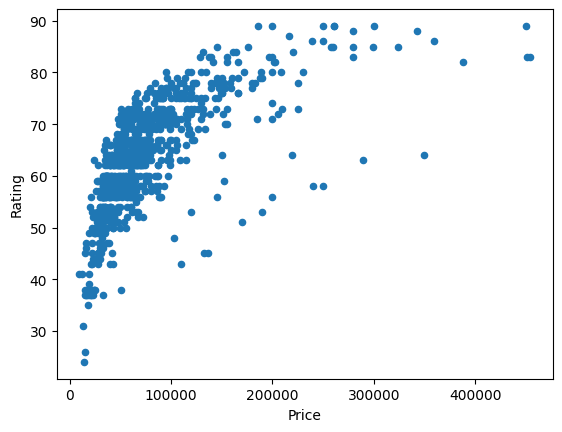

In [214]:
df.plot('Price', 'Rating', kind='scatter')

Есть взаимосвязь между ценой и рейтингом, что логично, ведь чем дороже ноутбук, тем он, скорее всего, качественнее, а значит и оценки выше

***2. Цена и число ядер***

In [215]:
ct_price_processor = pd.crosstab(df['Price_decile'], df['processor_brand'])
ct_price_processor

processor_brand,amd,apple,intel,other
Price_decile,,,,
1.0,23,0,64,3
2.0,26,0,62,1
3.0,31,0,60,0
4.0,31,0,57,0
5.0,25,0,63,0
6.0,28,0,64,0
7.0,22,1,58,0
8.0,15,0,74,0
9.0,20,4,62,0


Удалим объекты с процессорами от apple и неизвестными, потому что их слишком мало в выборке

In [216]:
new_df = df[df['processor_brand'].isin(['amd', 'intel'])].copy()
ct_price_processor = pd.crosstab(new_df['Price_decile'], new_df['processor_brand'])
ct_price_processor

processor_brand,amd,intel
Price_decile,,
1.0,23,64
2.0,26,62
3.0,31,60
4.0,31,57
5.0,25,63
6.0,28,64
7.0,22,58
8.0,15,74
9.0,20,62


По таблице трудно что-то сказать, надо смотреть на тест Хи-квадрат

In [217]:
res = stats.chi2_contingency(ct_price_processor)
res[3]

array([[23.10623557, 63.89376443],
       [23.37182448, 64.62817552],
       [24.16859122, 66.83140878],
       [23.37182448, 64.62817552],
       [23.37182448, 64.62817552],
       [24.43418014, 67.56581986],
       [21.24711316, 58.75288684],
       [23.63741339, 65.36258661],
       [21.77829099, 60.22170901],
       [21.51270208, 59.48729792]])

Частот меньше 5 нет, следовательно тест Хи-квадрат можно применить

In [218]:
print('chi2 = ', res[0], '   p-value =', res[1])

chi2 =  21.726946346414856    p-value = 0.009785834671847552


**Вывод**
H0: отсутствует взаимосвязь между ценой и брендом процессора

H1: существует взаимосвязь между ценой и брендом процессора

p-value < 0.05 (стандартный уровень значимости - 5%)

Гипотеза H1 принимается


<Axes: xlabel='Price', ylabel='processor_brand'>

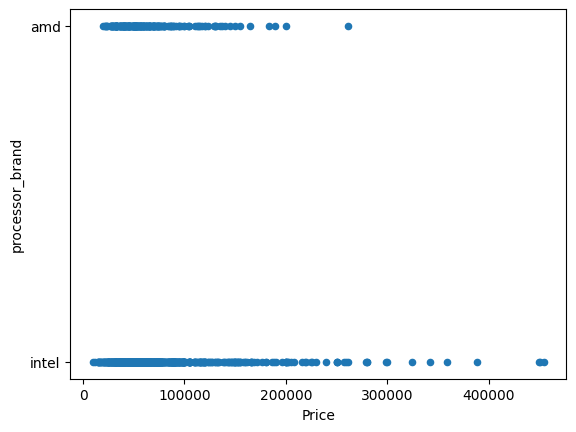

In [219]:
new_df.plot('Price', 'processor_brand', kind='scatter')

Взаимосвязь есть, что логично, ведь, чем больше ядер у процессора, тем больше стоило его производство, тем он дороже

### Задание 3. Парная корреляция

Проведите корреляционный анализ переменных (нужно рассмотреть не менее трёх разных пар переменных). Обоснуйте выбор рассчитываемых коэффициентов корреляции. Сформулируйте гипотезы. Визуализируйте наблюдаемые тенденции на подходящих графиках. Интерпретируйте результаты анализа (статистическая значимость, сила и направление взаимосвязи). Заполните таблицу (не менее 3 записей).

| Анализируемые пары переменных | Выбранный коэффициент корреляции (обоснование выбора) | Гипотезы | Сила взаимосвязи | Направление взаимосвязи | Статистическая значимость взаимосвязи |
| --- | --- | --- | --- | --- | --- |
| Price и num_cores | Кендалла(не норм. распр., мало уникальных) | имеется взаимосвязь | средняя | положительное | чем больше ядер, тем больше цена |
| Price и Rating | Кендалла(не норм. распр., мало уникальных) | имеется взаимосвязь | средняя | положительное | чем выше цена, тем больше рейтинг |
| Price и primary_storage_capacity | Кендалла(не норм. распр., мало уникальных) | имеется взаимосвязь | средняя | положительное | чем больше ёмкости памяти процессора, тем выше цена |


In [220]:


df.corr(numeric_only=True)

,index,Price,Rating,num_cores,num_threads,ram_memory,primary_storage_capacity,secondary_storage_capacity,display_size,resolution_width,resolution_height,Rating_decile,Price_decile
index,1.000000,0.105632,0.039843,0.034060,0.019061,0.032512,0.064017,0.013821,-0.052590,0.064690,0.032269,0.031075,0.116935
Price,0.105632,1.000000,0.659263,0.725934,0.716827,0.612126,0.636234,-0.026986,0.207328,0.628331,0.618031,0.614451,0.781836
Rating,0.039843,0.659263,1.000000,0.592667,0.770888,0.648302,0.597948,0.039144,0.349601,0.430428,0.423911,0.950142,0.753508
num_cores,0.034060,0.725934,0.592667,1.000000,0.905952,0.567477,0.498138,-0.059610,0.186638,0.485772,0.475888,0.554641,0.738807
num_threads,0.019061,0.716827,0.770888,0.905952,1.000000,0.630614,0.576075,-0.043330,0.313519,0.455543,0.447070,0.725121,0.781002
ram_memory,0.032512,0.612126,0.648302,0.567477,0.630614,1.000000,0.523424,0.002707,0.131952,0.405425,0.416383,0.612671,0.642597
primary_storage_capacity,0.064017,0.636234,0.597948,0.498138,0.576075,0.523424,1.000000,0.158977,0.225243,0.392610,0.384133,0.521647,0.552363
secondary_storage_capacity,0.013821,-0.026986,0.039144,-0.059610,-0.043330,0.002707,0.158977,1.000000,0.022411,-0.053718,-0.059898,0.046357,-0.002905
display_size,-0.052590,0.207328,0.349601,0.186638,0.313519,0.131952,0.225243,0.022411,1.000000,0.052487,-0.018724,0.304411,0.152442
resolution_width,0.064690,0.628331,0.430428,0.485772,0.455543,0.405425,0.392610,-0.053718,0.052487,1.000000,0.812020,0.388817,0.527927


***1. Цена и число ядер***

In [221]:
df1 = df[['Price','num_cores']].dropna()
stats.kendalltau(df1['Price'], df1['num_cores'])

SignificanceResult(statistic=np.float64(0.6147042850859805), pvalue=np.float64(8.381958304109725e-148))

H0: нет взаимосвязи между ценой и числом ядер

H1: существует взаимосвязь между ценой и числом ядер

Статистическая значимость взаимосвязи: поскольку p-value < 0.05, гипотеза H1 подтвердилась.
    Направление взаимосвязи: коэффициент корреляции положительный, следовательно, между переменными наблюдается прямая взаимосвязь.
    Сила взаимосвязи: коэффициент корреляции равен 0.61, следовательно, между переменными наблюдается средняя корреляция.


<Axes: xlabel='Price', ylabel='num_cores'>

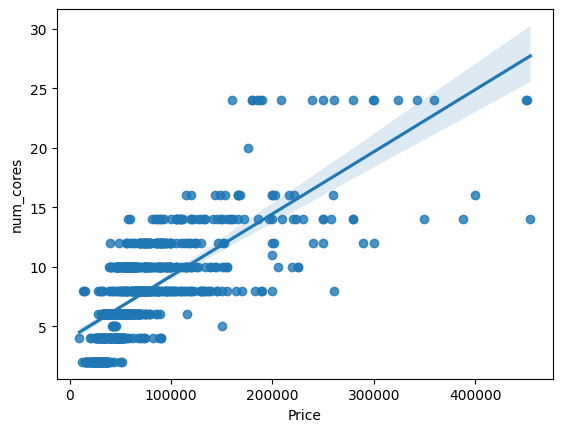

In [222]:
sns.regplot(data = df1, x = 'Price', y = 'num_cores')

***2. Цена и рейтинг***

In [223]:
df1 = df[['Price','Rating']].dropna()
stats.kendalltau(df1['Price'], df1['Rating'])

SignificanceResult(statistic=np.float64(0.6011779553427982), pvalue=np.float64(5.029610646238081e-153))

<Axes: xlabel='Price', ylabel='Rating'>

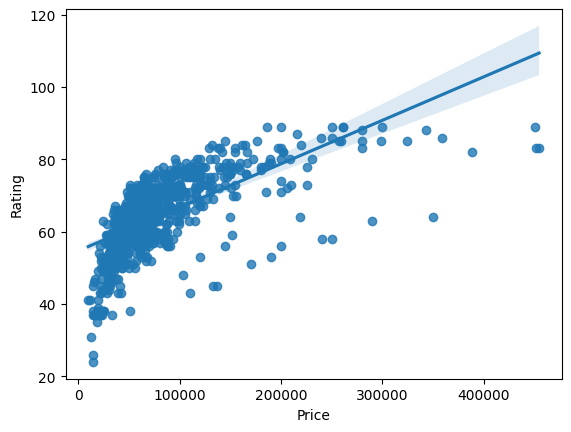

In [224]:
sns.regplot(data = df1, x = 'Price', y = 'Rating')

H0: нет взаимосвязи между ценой и рейтингом

H1: существует взаимосвязь между ценой и рейтингом

Статистическая значимость взаимосвязи: поскольку p-value < 0.05, гипотеза H1 подтвердилась.
    Направление взаимосвязи: коэффициент корреляции положительный, следовательно, между переменными наблюдается прямая взаимосвязь.
    Сила взаимосвязи: коэффициент корреляции равен 0.60, следовательно, между переменными наблюдается средняя корреляция.


***3. Цена и ёмкость основного хранилища ноутбука***

In [225]:
df1 = df[['Price','primary_storage_capacity']].dropna()
stats.kendalltau(df1['Price'], df1['primary_storage_capacity'])

SignificanceResult(statistic=np.float64(0.4810628751578468), pvalue=np.float64(2.8852491749283165e-72))

<Axes: xlabel='Price', ylabel='primary_storage_capacity'>

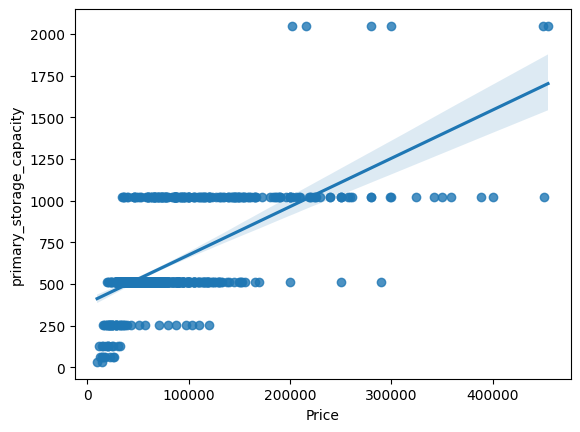

In [226]:
sns.regplot(data = df1, x = 'Price', y = 'primary_storage_capacity')

H0: нет взаимосвязи между ценой и ёмкостью ноутбука

H1: существует взаимосвязь между ценой и ёмкостью ноутбука

Статистическая значимость взаимосвязи: поскольку p-value < 0.05, гипотеза H1 подтвердилась.
    Направление взаимосвязи: коэффициент корреляции положительный, следовательно, между переменными наблюдается прямая взаимосвязь.
    Сила взаимосвязи: коэффициент корреляции равен 0.48, следовательно, между переменными наблюдается средняя корреляция.


### Задание 4. Частная корреляция
Посчитайте парный коэффициент корреляции между выбранной парой переменных. Посчитайте частный коэффициент корреляции между этими переменными, исключив влияние любой третьей переменной. Сделайте выводы. Визуализируйте наблюдаемые тенденции на подходящих графиках.

In [227]:
df1 = df[['Rating','num_threads','Price']].dropna()
stats.spearmanr(df1['Rating'], df1['num_threads'])

SignificanceResult(statistic=np.float64(0.7633604350087753), pvalue=np.float64(1.2469866023296123e-164))

Коэффицент корреляции между рейтингом и количеством поддерживающих потоков достаточно высокий(0,76), теперь проконтролируем влияние цены на эту корреляцию.

In [228]:
pg.partial_corr(data=df1, x='Rating',
                y='num_threads',
                covar='Price', method = 'spearman')

,n,r,CI95%,p-val
spearman,858,0.3842,"[0.33, 0.44]",1.571912e-31


Можно сделать вывод, что корреляция между рейтингом и количеством потоков, подерживаемых процессором достаточно сильно изменилась(с 0,76 до 0,38) после того, как мы исключили влияние на их корреляцию переменной, характеризующей цену ноутбука.

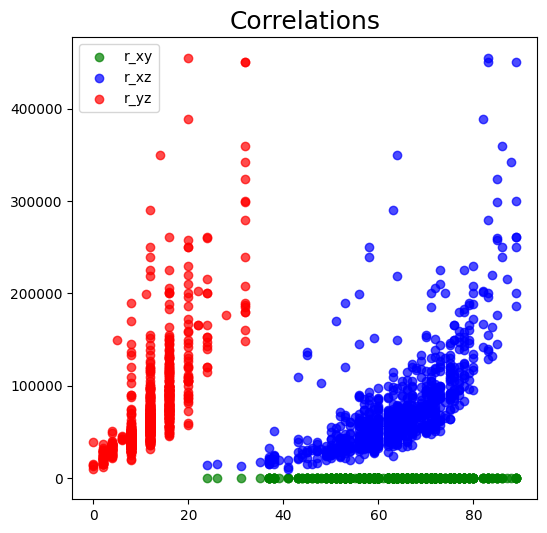

In [229]:
plt.figure(figsize=(6, 6))

plt.scatter(df1.Rating, df1.num_threads, c='g', alpha=0.7, label='r_xy')
plt.scatter(df1.Rating, df1.Price, c='b', alpha=0.7, label='r_xz')
plt.scatter(df1.num_threads, df1.Price, c='r', alpha=0.7, label='r_yz')
plt.title('Correlations', fontsize=18)
plt.legend()
plt.show()



**Комментарии к заданию и принципам его оценивания:**

- Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
- Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
- Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение методов оценки взаимосвязей между переменными и их применение для анализа данных, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях инструментов.
- В этом задании четыре пункта. Каждый из них весит 25%.
- Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
- В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.
- В случае использования в работе ИИ необходимо указать где и как именно он использовался.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 14 октября.

- При сдаче работы до 23:55 15 октября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 16 октября вычитаются 2 балла из итоговой оценки.
- После **23:55 16 октября** работа не принимается.